In [1]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "6"
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.optimize import minimize
os.chdir(r"C:\Users\ulsi\OneDrive - ATP\Dokumenter")

os.environ["OMP_NUM_THREADS"] = "6"   # actual fix for the KMeans/MKL warning

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="Model is not converging")

def ols(y, x):
    """Plain OLS with an intercept: y = alpha + beta*x + resid.

    Returns
    -------
    alpha, beta : float
    cov         : (2, 2) covariance of [alpha, beta]  -> usable as P0
    sigma2      : residual variance                   -> usable as sigma_eps
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    if len(y) != len(x):
        raise ValueError(f"y and x must be the same length ({len(y)} vs {len(x)}).")

    ok = np.isfinite(y) & np.isfinite(x)
    y, x = y[ok], x[ok]
    n = len(y)
    if n < 3:
        raise ValueError(f"Need at least 3 usable observations for OLS, got {n}.")

    X = np.column_stack([np.ones(n), x])
    XtX_inv = np.linalg.inv(X.T @ X)
    coef = XtX_inv @ X.T @ y                        # [alpha, beta]
    alpha, beta = coef[0], coef[1]
    resid = y - X @ coef
    dof = n - X.shape[1]
    sigma2 = (resid @ resid) / dof                  # residual variance -> sigma_eps
    cov = sigma2 * XtX_inv                          # covariance of [alpha, beta] -> P0
    return alpha, beta, cov, sigma2


def _filter_core(y, x, x0, P0, sigma_eta, sigma_eps, collect=True):
    """The Kalman recursion. Single source of truth -- both kalman_regression
    and kalman_loglikelihood run through here, so the math exists in one place.

        y_k = alpha_k + beta_k * x_k + eps_k        (measurement equation)
        alpha_k = alpha_{k-1} + eta_alpha_k          (process equation)
        beta_k  = beta_{k-1}  + eta_beta_k           (process equation)

    F = identity, H_k = [1, x_k].

    Missing observations (NaN in y or x) skip the update step: with no
    measurement there is nothing to update on, so the prediction carries
    forward and P keeps growing by sigma_eta.

    collect=False skips storing the per-step arrays (used by the optimizer,
    which only needs the log-likelihood).

    Returns
    -------
    dict of arrays (empty if collect=False) plus 'loglik'.
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    n = len(y)

    state = np.asarray(x0, dtype=float).reshape(2)      # [alpha, beta], x_{0|0}
    P = np.asarray(P0, dtype=float).reshape(2, 2)        # P_{0|0}
    Q = np.diag(np.asarray(sigma_eta, dtype=float).reshape(2))
    sigma_eps = float(sigma_eps)

    if collect:
        alphas = np.full(n, np.nan)
        betas = np.full(n, np.nan)
        alphas_pred = np.full(n, np.nan)
        betas_pred = np.full(n, np.nan)
        Ps = np.full((n, 2, 2), np.nan)
        residuals = np.full(n, np.nan)
        S_arr = np.full(n, np.nan)
        K_arr = np.full((n, 2), np.nan)
        observed = np.zeros(n, dtype=bool)

    loglik = 0.0
    for k in range(n):
        # ---- predict: x_{k|k-1}, P_{k|k-1} ----
        # F is the identity, so the state is unchanged; only P grows.
        P = P + Q

        if collect:
            alphas_pred[k] = state[0]      # prior estimate, has NOT seen y[k].
            betas_pred[k] = state[1]       # use these for prediction/backtests.

        # ---- missing data: no measurement, so no update ----
        if not (np.isfinite(y[k]) and np.isfinite(x[k])):
            if collect:
                alphas[k], betas[k] = state[0], state[1]
                Ps[k] = P
            continue

        h = np.array([1.0, x[k]])                    # H_k

        # ---- helper steps: residual, S, Kalman gain ----
        Ph = P @ h                                    # (2,)
        S = h @ Ph + sigma_eps                        # scalar (S is 1x1 here)
        if not np.isfinite(S) or S <= 0:
            # degenerate parameters: tell the optimizer this is a bad candidate
            return {"loglik": -np.inf} if not collect else None
        r = y[k] - h @ state
        K = Ph / S                                    # (2,)

        # ---- update: x_{k|k}, P_{k|k} ----
        state = state + K * r
        P = P - np.outer(K, Ph)                       # symmetric by construction

        loglik += -0.5 * (np.log(2 * np.pi) + np.log(S) + (r * r) / S)

        if collect:
            alphas[k], betas[k] = state[0], state[1]
            Ps[k] = P
            residuals[k] = r
            S_arr[k] = S
            K_arr[k] = K
            observed[k] = True

    if not collect:
        return {"loglik": loglik}

    return {
        "alpha": alphas,
        "beta": betas,
        "alpha_pred": alphas_pred,
        "beta_pred": betas_pred,
        "P": Ps,
        "residual": residuals,
        "S": S_arr,
        "K": K_arr,
        "observed": observed,
        "loglik": loglik,
    }


def kalman_loglikelihood(y, x, x0, P0, sigma_eta, sigma_eps):
    """Score one candidate (sigma_eta, sigma_eps) pair:

        log L = -1/2 * sum_k( log(2*pi) + log(S_k) + r_k^2 / S_k )

    Does not search -- it evaluates a single candidate, so an optimizer can
    call it repeatedly. Returns -inf for degenerate parameters.
    """
    return _filter_core(y, x, x0, P0, sigma_eta, sigma_eps, collect=False)["loglik"]


def calibrate_sigmas_mle(y, x, initial_sigma_eta=None, n_starts=3, seed=0):
    """Estimate sigma_eta ([var_eta_alpha, var_eta_beta]) and sigma_eps by MLE.

    x0 and P0 come from ols(y, x) and are held FIXED during the search --
    only the two noise parameters are optimized. The search runs in log-space
    so the optimizer can never propose a negative variance.

    n_starts > 1 repeats the search from perturbed starting points and keeps
    the best result, since the log-likelihood can be flat or have local
    maxima in sigma_eta.

    Returns
    -------
    dict: 'x0', 'P0', 'sigma_eta', 'sigma_eps', 'loglik', 'converged',
          'n_iter', 'all_logliks'
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    if len(y) != len(x):
        raise ValueError(f"y and x must be the same length ({len(y)} vs {len(x)}).")

    alpha, beta, cov, sigma2 = ols(y, x)
    x0 = np.array([alpha, beta])
    P0 = cov

    if initial_sigma_eta is None:
        initial_sigma_eta = np.maximum(np.diag(P0) * 0.01, 1e-10)
    initial_sigma_eta = np.asarray(initial_sigma_eta, dtype=float).reshape(2)

    base = np.concatenate([np.log(initial_sigma_eta), [np.log(sigma2)]])

    def neg_loglik(log_params):
        ll = kalman_loglikelihood(
            y, x, x0, P0, np.exp(log_params[:2]), np.exp(log_params[2])
        )
        return -ll if np.isfinite(ll) else 1e10   # finite penalty keeps the search stable

    rng = np.random.default_rng(seed)
    best, all_logliks = None, []
    for i in range(max(1, n_starts)):
        start = base if i == 0 else base + rng.normal(0.0, 1.5, size=3)
        res = minimize(neg_loglik, start, method="Nelder-Mead",
                       options={"maxiter": 5000, "xatol": 1e-8, "fatol": 1e-8})
        all_logliks.append(-res.fun)
        if best is None or res.fun < best.fun:
            best = res

    return {
        "x0": x0,
        "P0": P0,
        "sigma_eta": np.exp(best.x[:2]),
        "sigma_eps": np.exp(best.x[2]),
        "loglik": -best.fun,
        "converged": bool(best.success),
        "n_iter": int(best.nit),
        "all_logliks": np.array(all_logliks),
    }


def kalman_regression(y, x, dates, x0, P0, sigma_eta, sigma_eps):
    """Kalman filter estimate of a time-varying linear regression.

    Parameters
    ----------
    y, x   : array-like, shape (n,). Observed series; NaNs are handled.
    dates  : array-like, shape (n,). Passed straight through.
    x0     : [alpha_0, beta_0]
    P0     : (2, 2) initial state covariance
    sigma_eta : [var_eta_alpha, var_eta_beta]
    sigma_eps : float, measurement noise variance

    Returns
    -------
    dict with keys:
        'dates'
        'alpha', 'beta'            filtered (posterior) estimates, x_{k|k}
        'alpha_pred', 'beta_pred'  predicted (prior) estimates, x_{k|k-1}.
                                   
        'P'                        (n, 2, 2) posterior covariance
        'residual', 'S', 'K'       helper quantities (NaN where no observation)
        'observed'                 bool mask: was there a measurement that day
        'loglik'                   log-likelihood of this parameter set
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    dates = np.asarray(dates)
    if not (len(y) == len(x) == len(dates)):
        raise ValueError(
            f"y, x and dates must be the same length ({len(y)}, {len(x)}, {len(dates)})."
        )

    out = _filter_core(y, x, x0, P0, sigma_eta, sigma_eps, collect=True)
    if out is None:
        raise ValueError(
            "Filter hit a non-positive innovation variance S. Check that "
            "sigma_eps > 0 and that P0/sigma_eta are sensible."
        )
    out["dates"] = dates
    return out

In [2]:

kalman_df = pd.read_excel("Kalman_filter_data.xlsx")
#ols_mle_df = pd.read_excel("OLS_MLE_estimation.xlsx")

print(kalman_df.shape, kalman_df.columns.tolist())
print(kalman_df.head())
print(kalman_df.tail())
print()


EURUSD_kalman = kalman_df["EURUSD"]
EURUSD_kalman_diff = np.log(EURUSD_kalman).diff()

Yield_spread_kalman = kalman_df["EUR Swap OIS 3m"] - kalman_df["USD Swap OIS 3m"]
Yield_spread_kalman_change = Yield_spread_kalman.diff()

mask = EURUSD_kalman_diff.notna() & Yield_spread_kalman_change.notna()
EURUSD_kalman_diff = EURUSD_kalman_diff[mask]
Yield_spread_kalman_change = Yield_spread_kalman_change[mask]
dates_kalman = kalman_df["Dates"][mask]

"""
EURUSD_ols_mle = ols_mle_df["EURUSD Curncy"]
EURUSD_ols_mle_diff = np.log(EURUSD_ols_mle).diff()

Yield_spread_ols_mle = ols_mle_df["GECU2YR Index"] - ols_mle_df["USGG2YR Index"]
Yield_spread_ols_mle_change = Yield_spread_ols_mle.diff()

mask = EURUSD_ols_mle_diff.notna() & Yield_spread_ols_mle_change.notna()
EURUSD_ols_mle_diff = EURUSD_ols_mle_diff[mask]
Yield_spread_ols_mle_change = Yield_spread_ols_mle_change[mask]
dates_ols_mle = ols_mle_df["Dates"][mask]

alpha_weekly, beta_weekly, cov_weekly, sigma2_weekly = ols(
    EURUSD_ols_mle_diff.values, Yield_spread_ols_mle_change.values
)

"""





(4871, 4) ['Dates', 'USD Swap OIS 3m', 'EUR Swap OIS 3m', 'EURUSD']
       Dates  USD Swap OIS 3m  EUR Swap OIS 3m  EURUSD
0 2007-12-31           4.0395           3.9570  1.4589
1 2008-01-01           4.0525           3.9570  1.4592
2 2008-01-02           3.9925           3.9585  1.4715
3 2008-01-03           3.9555           3.9560  1.4750
4 2008-01-04           3.8850           3.9610  1.4743
          Dates  USD Swap OIS 3m  EUR Swap OIS 3m  EURUSD
4866 2026-08-25          3.73549           2.3934  1.1675
4867 2026-08-26          3.74300           2.4035  1.1651
4868 2026-08-27          3.74296           2.4098  1.1653
4869 2026-08-28          3.79760           2.4112  1.1585
4870 2026-08-31          3.81187           2.4170  1.1600



'\nEURUSD_ols_mle = ols_mle_df["EURUSD Curncy"]\nEURUSD_ols_mle_diff = np.log(EURUSD_ols_mle).diff()\n\nYield_spread_ols_mle = ols_mle_df["GECU2YR Index"] - ols_mle_df["USGG2YR Index"]\nYield_spread_ols_mle_change = Yield_spread_ols_mle.diff()\n\nmask = EURUSD_ols_mle_diff.notna() & Yield_spread_ols_mle_change.notna()\nEURUSD_ols_mle_diff = EURUSD_ols_mle_diff[mask]\nYield_spread_ols_mle_change = Yield_spread_ols_mle_change[mask]\ndates_ols_mle = ols_mle_df["Dates"][mask]\n\nalpha_weekly, beta_weekly, cov_weekly, sigma2_weekly = ols(\n    EURUSD_ols_mle_diff.values, Yield_spread_ols_mle_change.values\n)\n\n'

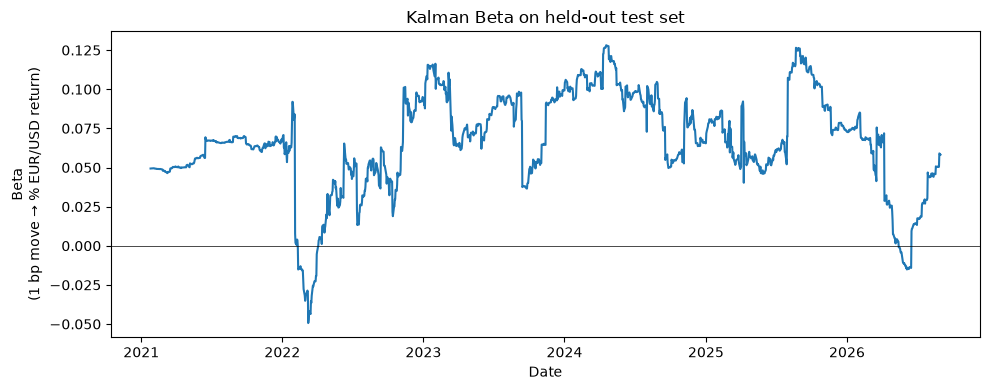

In [ ]:
#Test sigmas, x0 and P0
x0 = np.array([0.01, 0.1])
P0 = 0.1 * np.eye(2)

eta_alpha = 0.0000001
eta_beta = 0.00002407
sigma_eta = [eta_alpha, eta_beta]
sigma_eps = 1.9651262465924437e-05


result_kalman = kalman_regression(
    EURUSD_kalman_diff.values,
    Yield_spread_kalman_change.values,
    dates_kalman.values,
    x0, P0, sigma_eta, sigma_eps,
)



# split chronologically -- train first, test after
split_idx = int(len(EURUSD_kalman_diff) * 0.7)   # e.g. 70% train, 30% test

y_train = EURUSD_kalman_diff.values[:split_idx]
x_train = Yield_spread_kalman_change.values[:split_idx]

y_test = EURUSD_kalman_diff.values[split_idx:]
x_test = Yield_spread_kalman_change.values[split_idx:]
dates_test = dates_kalman.values[split_idx:]

calib = calibrate_sigmas_mle(y_train, x_train)

result_kalman = kalman_regression(
    y_test, x_test, dates_test,
    calib["x0"], calib["P0"], calib["sigma_eta"], calib["sigma_eps"],
)


beta_values = result_kalman["beta"].reshape(-1, 1)

plt.figure(figsize=(10, 4))
plt.plot(dates_test, result_kalman["beta"])
plt.axhline(0, color="black", linewidth=0.5)
plt.title("Kalman Beta on held-out test set")
plt.xlabel("Date")
plt.ylabel("Beta\n(1 bp move → % EUR/USD return)")
plt.tight_layout()
plt.show()

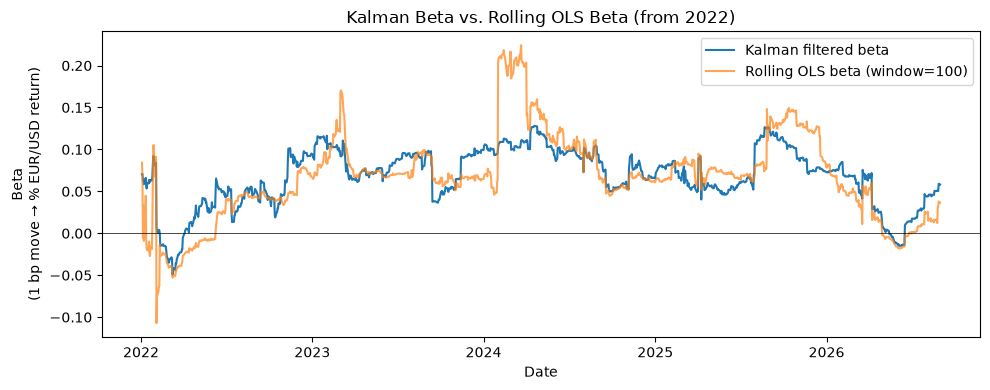

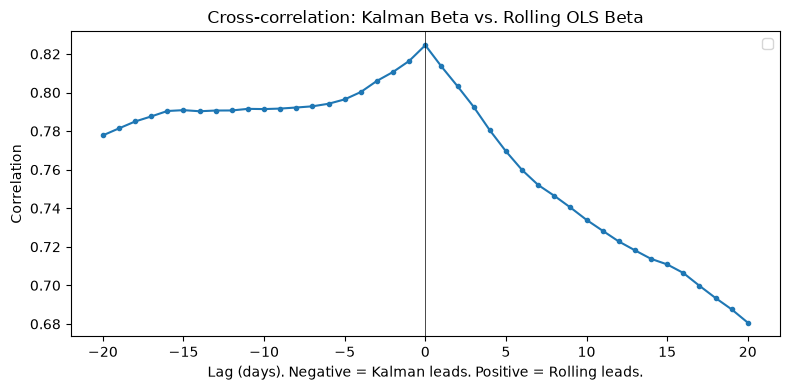

In [6]:
# --- rolling OLS beta, for comparison ---
window = 100
y_series = pd.Series(y_test, index=dates_test)
x_series = pd.Series(x_test, index=dates_test)
rolling_beta = y_series.rolling(window).cov(x_series) / x_series.rolling(window).var()

plot_mask = dates_test >= np.datetime64("2022-01-01")

plt.figure(figsize=(10, 4))
plt.plot(dates_test[plot_mask], result_kalman["beta"][plot_mask], label="Kalman filtered beta")
plt.plot(dates_test[plot_mask], rolling_beta.values[plot_mask], label=f"Rolling OLS beta (window={window})", alpha=0.7)
plt.axhline(0, color="black", linewidth=0.5)
plt.legend()
plt.title("Kalman Beta vs. Rolling OLS Beta (from 2022)")
plt.xlabel("Date")
plt.ylabel("Beta\n(1 bp move → % EUR/USD return)")
plt.tight_layout()
plt.show()



plot_mask = dates_test >= np.datetime64("2022-01-01")

kalman_beta_sub = result_kalman["beta"][plot_mask]
rolling_beta_sub = rolling_beta.values[plot_mask]

# drop rows where either series is NaN (rolling beta still has some at the very start)
valid = np.isfinite(kalman_beta_sub) & np.isfinite(rolling_beta_sub)
kalman_beta_sub = kalman_beta_sub[valid]
rolling_beta_sub = rolling_beta_sub[valid]

max_lag = 20   # in trading days
lags = range(-max_lag, max_lag + 1)
correlations = []

for lag in lags:
    if lag < 0:
        # kalman shifted back by |lag| vs rolling -- tests "does kalman lead rolling by |lag| days"
        a, b = kalman_beta_sub[:lag], rolling_beta_sub[-lag:]
    elif lag > 0:
        # rolling shifted back by lag vs kalman -- tests "does rolling lead kalman by lag days"
        a, b = kalman_beta_sub[lag:], rolling_beta_sub[:-lag]
    else:
        a, b = kalman_beta_sub, rolling_beta_sub
    correlations.append(pearsonr(a, b)[0])

correlations = np.array(correlations)
best_lag = list(lags)[np.argmax(correlations)]

plt.figure(figsize=(8, 4))
plt.plot(list(lags), correlations, marker="o", markersize=3)
plt.axvline(0, color="black", linewidth=0.5)
#plt.axvline(best_lag, color="red", linestyle="--", label=f"best lag = {best_lag}")
plt.xlabel("Lag (days). Negative = Kalman leads. Positive = Rolling leads.")
plt.ylabel("Correlation")
plt.title("Cross-correlation: Kalman Beta vs. Rolling OLS Beta")
plt.legend()
plt.tight_layout()
plt.show()


c:\Users\ulsi\.conda\envs\py314\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Model is not converging.  Current: 3619.7405129501362 is not greater than 3619.893216284958. Delta is -0.15270333482158094
Model is not converging.  Current: 4288.167086036374 is not greater than 4288.205275852634. Delta is -0.0381898162604557
Model is not converging.  Current: 4288.159261813102 is not greater than 4288.202879503258. Delta is -0.0436176901566796
Model is not converging.  Current: 4288.126698361797 is not greater than 4288.1296056483. Delta is 

Best state means: [0.06046878 0.09800985 0.01219723]
Best transition matrix:
 [[9.83576970e-01 1.22456682e-02 4.17736155e-03]
 [1.36134672e-02 9.82505628e-01 3.88090470e-03]
 [2.29573450e-02 3.55544228e-32 9.77042655e-01]]


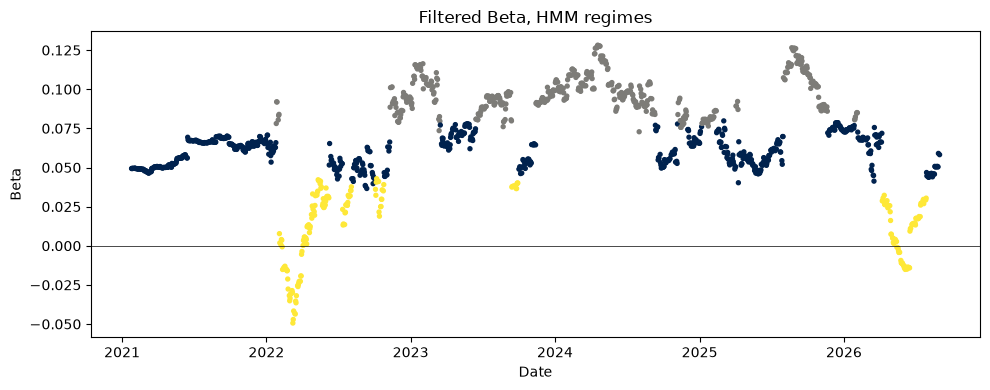

In [7]:
from hmmlearn.hmm import GaussianHMM

n_range = range(1, 6)
bics_hmm = []
for n in n_range:
    model = GaussianHMM(n_components=n, covariance_type="diag", n_iter=200, random_state=0)
    model.fit(beta_values)
    log_lik = model.score(beta_values)
    n_params = n * n + 2 * n - 1   # transition matrix + means + variances, roughly
    bic = -2 * log_lik + n_params * np.log(len(beta_values))
    bics_hmm.append(bic)


# 1. Try multiple random restarts, keep the best-scoring one
best_model, best_score = None, -np.inf
for seed in range(10):
    m = GaussianHMM(n_components=3, covariance_type="diag", n_iter=500, random_state=seed)
    m.fit(beta_values)
    score = m.score(beta_values)
    if score > best_score:
        best_model, best_score = m, score

print("Best state means:", best_model.means_.flatten())
print("Best transition matrix:\n", best_model.transmat_)


hmm_labels = best_model.predict(beta_values)

plt.figure(figsize=(10, 4))
plt.scatter(dates_test, result_kalman["beta"], c=hmm_labels, cmap="cividis", s=8)
plt.axhline(0, color="black", linewidth=0.5)
plt.title("Filtered Beta, HMM regimes")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.tight_layout()
plt.show()



In [8]:
from scipy.stats import skew, kurtosis

# --- regime assignment, ranked low -> high by beta ---
order = np.argsort(best_model.means_.flatten())
rank_map = {state_idx: rank for rank, state_idx in enumerate(order)}
hmm_labels_ranked = np.array([rank_map[l] for l in hmm_labels])

regime_names = ["Low", "Medium", "High"]
moments = ["Mean", "Variance", "Skewness", "Kurtosis"]
trading_days = 252

# --- moments table (daily) ---
table = pd.DataFrame(index=moments, columns=regime_names, dtype=float)
for rank, name in enumerate(regime_names):
    y_regime = y_test[hmm_labels_ranked == rank]
    table.loc["Mean", name] = y_regime.mean()
    table.loc["Variance", name] = y_regime.var()
    table.loc["Skewness", name] = skew(y_regime)
    table.loc["Kurtosis", name] = kurtosis(y_regime)

print("Daily moments by regime:")
print(table)
print()

# --- day counts per regime, for context on how reliable skew/kurtosis are ---
print("Days per regime:")
for rank, name in enumerate(regime_names):
    n_days = (hmm_labels_ranked == rank).sum()
    print(f"  {name}: {n_days} days")
print()

# --- annualized mean return ---
print("Annualized mean return:")
for name in regime_names:
    daily_mean = table.loc["Mean", name]
    annualized_mean = daily_mean * trading_days
    print(f"  {name}: daily = {daily_mean:.6f}, annualized ≈ {annualized_mean:.4%}")
print()

# --- annualized volatility ---
print("Annualized volatility:")
for name in regime_names:
    daily_std = np.sqrt(table.loc["Variance", name])
    annualized_vol = daily_std * np.sqrt(trading_days)
    print(f"  {name}: daily std = {daily_std:.5f}, annualized vol ≈ {annualized_vol:.2%}")

Daily moments by regime:
               Low    Medium      High
Mean     -0.000240 -0.000082  0.000125
Variance  0.000025  0.000022  0.000019
Skewness  0.373660  0.056903  0.488912
Kurtosis  0.723188  2.114259  1.765366

Days per regime:
  Low: 215 days
  Medium: 734 days
  High: 512 days

Annualized mean return:
  Low: daily = -0.000240, annualized ≈ -6.0471%
  Medium: daily = -0.000082, annualized ≈ -2.0673%
  High: daily = 0.000125, annualized ≈ 3.1380%

Annualized volatility:
  Low: daily std = 0.00497, annualized vol ≈ 7.89%
  Medium: daily std = 0.00464, annualized vol ≈ 7.37%
  High: daily std = 0.00441, annualized vol ≈ 7.00%


In [11]:
Yield_spread_kalman = kalman_df["EUR Swap OIS 3m"] - kalman_df["USD Swap OIS 3m"]
Yield_spread_kalman = Yield_spread_kalman.iloc[1:].reset_index(drop=True)   # drop first row to match the diffed series' length

print(len(Yield_spread_kalman), len(EURUSD_kalman_diff), len(Yield_spread_kalman_change))
mask_kalman = EURUSD_kalman_diff.notna().values & Yield_spread_kalman_change.notna().values
Yield_spread_kalman_lvl_aligned = Yield_spread_kalman.values[mask_kalman][split_idx:]

regime_avg_spread = {}
for rank, name in enumerate(regime_names):
    spread_regime = Yield_spread_kalman_lvl_aligned[hmm_labels_ranked == rank]
    regime_avg_spread[name] = spread_regime.mean()

print("Total annualized return by regime (spot + carry):")
for name in regime_names:
    annualized_spot_pct = table.loc["Mean", name] * trading_days * 100
    carry_pct = regime_avg_spread[name]
    total_pct = annualized_spot_pct + carry_pct
    print(f"  {name}: spot ≈ {annualized_spot_pct:.2f}%, carry ≈ {carry_pct:.2f}%, total ≈ {total_pct:.2f}%")

4870 4870 4870
Total annualized return by regime (spot + carry):
  Low: spot ≈ -6.05%, carry ≈ -1.61%, total ≈ -7.66%
  Medium: spot ≈ -2.07%, carry ≈ -1.46%, total ≈ -3.53%
  High: spot ≈ 3.14%, carry ≈ -1.77%, total ≈ 1.37%
